# 06 Checkout A/B test (one-page vs three-step checkout)
**Question:** is conversion-rate optimisation a credible non-media lever, how long must the test run, and how badly does 'peeking' inflate false wins?

Simulated test, about 4,000 sessions a day, 50/50 split, 28 days. *Prakriti Foods is fictional; all data is synthetic.* Variants are ethical by design: no pre-ticked add-ons, no fake urgency, no hidden costs (see governance charter).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
s = pd.read_csv('../data/stage2/cro_sessions.csv', parse_dates=['date'])
g = s.groupby('variant').agg(sessions=('converted','size'), conversions=('converted','sum')); g['rate'] = g.conversions/g.sessions; g

,sessions,conversions,rate
variant,,,
one_page,56182,1759,0.031309
three_step,55818,1608,0.028808


## 1. Sample-ratio-mismatch check (is the 50/50 split intact?)

In [2]:
chi = stats.chisquare(g.sessions.values); print(f'Chi-square on assignment counts: p = {chi.pvalue:.3f} -> ' + ('SRM flag raised (p < 0.001): do not trust the test' if chi.pvalue < 0.001 else 'no mismatch (flag only if p < 0.001)'))

Chi-square on assignment counts: p = 0.277 -> no mismatch (flag only if p < 0.001)


## 2. Power and run length (baseline 3.0%, alpha 0.05, power 80%)

In [3]:
p0 = 0.03; z = stats.norm.ppf(0.975) + stats.norm.ppf(0.80)
n_for = lambda rel: 2*z**2*p0*(1-p0)/(p0*rel)**2
daily_arm = 2000
tab = pd.DataFrame({'relative_lift': [0.05, 0.065, 0.08, 0.10]}); tab['sessions_per_arm'] = tab.relative_lift.map(n_for).round(0); tab['days_needed'] = (tab.sessions_per_arm/daily_arm).round(0)
n28 = 28*daily_arm; mde_abs = z*np.sqrt(2*p0*(1-p0)/n28); mde_rel = mde_abs/p0
print(f'With 28 days ({n28:,} sessions per arm): minimum detectable effect = {mde_abs:.4f} absolute = {mde_rel:.1%} relative')
tab

With 28 days (56,000 sessions per arm): minimum detectable effect = 0.0029 absolute = 9.5% relative


,relative_lift,sessions_per_arm,days_needed
0,0.050,203024.0,102.0
1,0.065,120133.0,60.0
2,0.080,79306.0,40.0
3,0.100,50756.0,25.0


## 3. The result with a confidence interval

In [4]:
a, b = g.loc['three_step'], g.loc['one_page']
d_ = b.rate - a.rate; se = np.sqrt(a.rate*(1-a.rate)/a.sessions + b.rate*(1-b.rate)/b.sessions)
zst = d_/se; pval = 2*(1-stats.norm.cdf(abs(zst)))
print(f'three-step {a.rate:.3%} | one-page {b.rate:.3%} | difference {d_:+.3%} (95% CI {d_-1.96*se:+.3%} to {d_+1.96*se:+.3%}) | relative {d_/a.rate:+.1%} (CI {(d_-1.96*se)/a.rate:+.1%} to {(d_+1.96*se)/a.rate:+.1%}) | p = {pval:.3f}')

three-step 2.881% | one-page 3.131% | difference +0.250% (95% CI +0.050% to +0.450%) | relative +8.7% (CI +1.7% to +15.6%) | p = 0.014


## 4. Peeking: 1,000 simulated A/A tests (no true difference), checking every day and stopping at the first p < 0.05

False-positive rate when peeking daily: 27.4% | when looking only once at day 28: 4.9% | nominal 5%


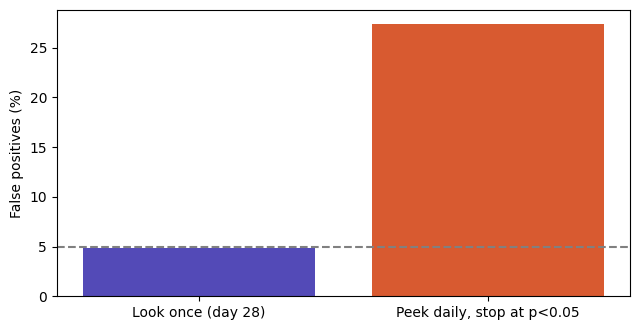

In [5]:
rs = np.random.default_rng(7); n_sim, days, per = 1000, 28, 2000
ca = rs.binomial(per, p0, (n_sim, days)).cumsum(1); cb = rs.binomial(per, p0, (n_sim, days)).cumsum(1); n = per*np.arange(1, days+1)
pa, pb = ca/n, cb/n; pp = (ca+cb)/(2*n); se_ = np.sqrt(2*pp*(1-pp)/n); pv = 2*(1-stats.norm.cdf(np.abs(pb-pa)/se_))
peek_fp = (pv < 0.05).any(axis=1).mean(); final_fp = (pv[:, -1] < 0.05).mean()
print(f'False-positive rate when peeking daily: {peek_fp:.1%} | when looking only once at day 28: {final_fp:.1%} | nominal 5%')
fig, ax = plt.subplots(figsize=(6.5,3.4)); ax.bar(['Look once (day 28)','Peek daily, stop at p<0.05'], [final_fp*100, peek_fp*100], color=['#534AB7','#D85A30']); ax.axhline(5, color='grey', ls='--'); ax.set_ylabel('False positives (%)'); plt.tight_layout(); plt.show()

## 5. Incremental revenue at current traffic (if the lift were real)

In [6]:
aov = s.loc[s.converted==1,'order_value'].mean(); sessions_year = 4000*365
for rel in [0.05, 0.065, 0.08]:
    extra = sessions_year*p0*rel*aov/1e7
    print(f'Relative lift {rel:.1%}: about Rs {extra:.2f} Cr a year of extra website revenue (average order Rs {aov:.0f})')
print('For scale: the brief targets about Rs 120 Cr of total revenue, with the website at about 20% of it.')

Relative lift 5.0%: about Rs 0.14 Cr a year of extra website revenue (average order Rs 645)
Relative lift 6.5%: about Rs 0.18 Cr a year of extra website revenue (average order Rs 645)
Relative lift 8.0%: about Rs 0.23 Cr a year of extra website revenue (average order Rs 645)
For scale: the brief targets about Rs 120 Cr of total revenue, with the website at about 20% of it.


## Answer

In [7]:
print(f'Observed lift {d_/a.rate:+.1%} (95% CI {(d_-1.96*se)/a.rate:+.1%} to {(d_+1.96*se)/a.rate:+.1%}), p = {pval:.3f}. The 28-day test can only reliably detect a relative lift of {mde_rel:.0%} or more; a true 5-8% lift would need roughly {int(n_for(0.08)/daily_arm)}-{int(n_for(0.05)/daily_arm)} days.')
print(f'Peeking daily turns a nominal 5% false-positive rate into {peek_fp:.0%}.')

Observed lift +8.7% (95% CI +1.7% to +15.6%), p = 0.014. The 28-day test can only reliably detect a relative lift of 10% or more; a true 5-8% lift would need roughly 39-101 days.
Peeking daily turns a nominal 5% false-positive rate into 27%.


**Interpretation.** (1) The test shows a +8.7% lift that is statistically significant (p = 0.014), but the interval is wide (+1.7% to +15.6%), and the test was only powered to detect about 10%. A significant result from an underpowered test tends to overstate the true lift, so I would plan for 5-8%, not 8.7%. (2) Peeking daily inflates the false-positive rate from 5% to 27%. (3) **CRO is not a material lever at this scale:** at about 4,000 checkout sessions a day, even an 8% lift is worth roughly Rs 0.2 Cr a year, about 0.2% of the Rs 120 Cr revenue base. It is cheap and worth doing, but it cannot offset a Rs 10 Cr budget cut. That answers decision question Q6: not credible as a replacement for media.